  <h1>



  Airbnb Price Prediction Project



  </h1>

  <h3>



  1) Problem Statement



  </h3>



  <p>



  The goal of this project is to predict Airbnb listing prices using structured listing data such as



  location, room type, review scores, host information, and availability.



  This notebook demonstrates a complete machine learning workflow, including data loading,



  exploratory analysis, data cleaning, feature engineering, model building, hyperparameter tuning,



  evaluation, and interpretation.



  </p>

In [1]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
CZK_TO_USD = 0.0485
DATA_DIR = Path("listings.csv")
MIN_ROWS_PER_CITY = 200
TOP_CITY_OUTLIER_Q = 0.99
MAX_COL_MISSING = 0.80



  <h3>



  2) Data Loading



  </h3>



  <p>



  In this section, Airbnb listings from all compatible files in the listings folder are loaded



  and combined. The Prague dataset is converted from Czech koruna to U.S. dollars so that all cities



  use the same currency scale.



  </p>

In [2]:
# =========================================
# 2. LOAD AND COMBINE MULTIPLE CITY DATASETS
# =========================================
def clean_price_column(series):
    cleaned = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("Kč", "", regex=False)
        .str.replace("CZK", "", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_city_name(filename):
    name = filename.replace("listings - ", "").replace(".csv", "")
    parts = [p.strip() for p in name.split(",")]
    city_short = parts[0]
    city_full = name
    return city_short, city_full


def load_all_city_data(data_dir):
    frames = []
    csv_files = sorted(data_dir.glob("listings - *.csv"))

    for file_path in csv_files:
        temp = pd.read_csv(file_path)
        city_short, city_full = parse_city_name(file_path.name)

        temp["city"] = city_short
        temp["city_full"] = city_full
        temp["price"] = clean_price_column(temp["price"])

        if "Prague" in city_full:
            temp["price"] = temp["price"] * CZK_TO_USD

        frames.append(temp)

    combined = pd.concat(frames, ignore_index=True)
    return combined


df = load_all_city_data(DATA_DIR)

print("Combined dataset shape:", df.shape)
print("\nRows by city:")
print(df["city_full"].value_counts())

print("\nAverage price by city after conversion:")
print(df.groupby("city_full")["price"].mean().sort_values(ascending=False))

print("\nMissing share by city:")
print(df.groupby("city_full")["price"].apply(lambda x: x.isna().mean()))



Combined dataset shape: (147012, 82)

Rows by city:
city_full
Hawaii, Hawaii                            33457
Broward County, Florida                   16822
Prague, Czech Republic                    10834
Austin, Texas                             10533
Nashville, Tennessee                       9443
Chicago, Illinois                          8663
New Orleans, Louisiana                     7444
Seattle, Washington                        6996
Washington, D.C., District of Columbia     6382
Rhode Island, Rhode Island                 5762
Twin Cities MSA, Minnesota                 5318
Denver, Colorado                           4910
San Mateo County, California               3516
Columbus, Ohio                             2877
Asheville, North Carolina                  2852
Oakland, California                        2250
Fort Worth, Texas                          2081
Jersey City, New Jersey                    1829
Santa Cruz County, California              1760
Cambridge, Massachusetts  

  <h3>



  3) Data Exploration



  </h3>



  <p>



  This section explores the structure of the dataset, missing values, and the distribution of prices.



  The plots help justify later preprocessing choices such as outlier handling and log transformation.



  </p>

Dataset shape: (147012, 82)

City counts before cleaning:
city_full
Hawaii, Hawaii                            33457
Broward County, Florida                   16822
Prague, Czech Republic                    10834
Austin, Texas                             10533
Nashville, Tennessee                       9443
Chicago, Illinois                          8663
New Orleans, Louisiana                     7444
Seattle, Washington                        6996
Washington, D.C., District of Columbia     6382
Rhode Island, Rhode Island                 5762
Twin Cities MSA, Minnesota                 5318
Denver, Colorado                           4910
San Mateo County, California               3516
Columbus, Ohio                             2877
Asheville, North Carolina                  2852
Oakland, California                        2250
Fort Worth, Texas                          2081
Jersey City, New Jersey                    1829
Santa Cruz County, California              1760
Cambridge, Massachus

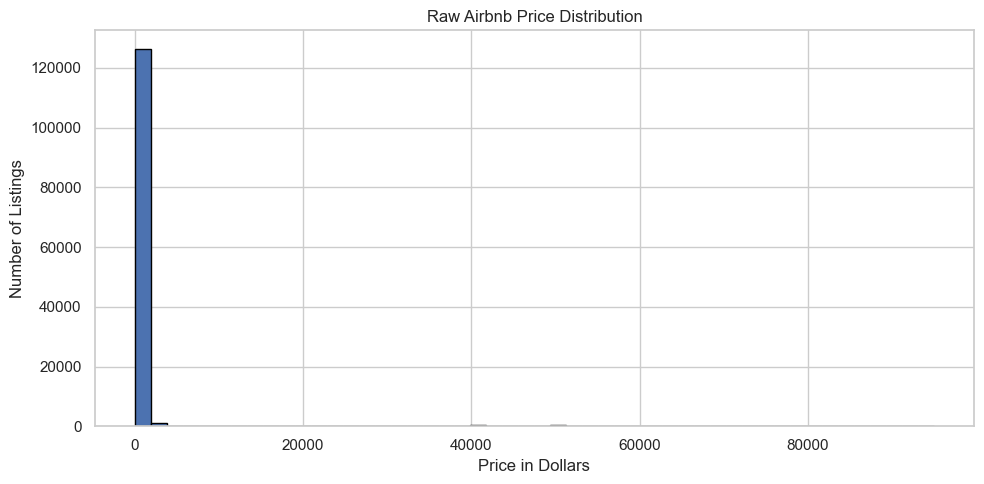

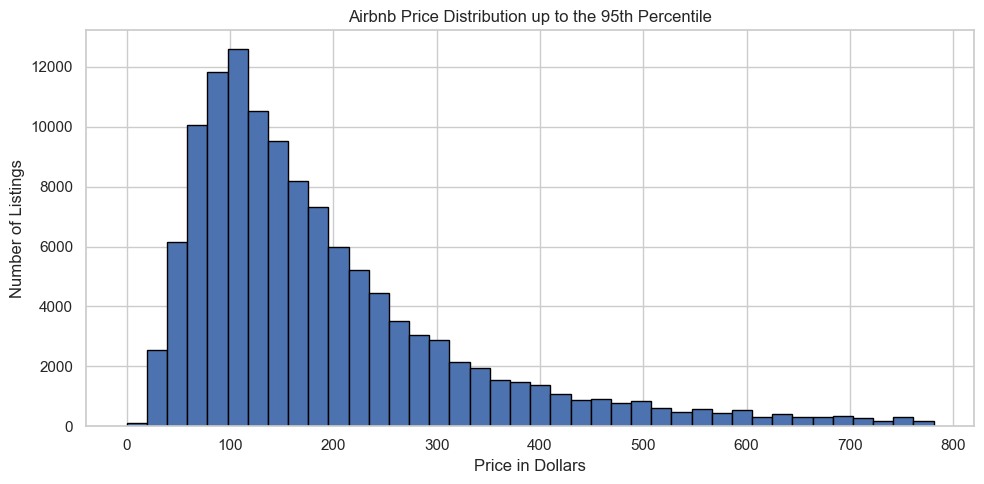

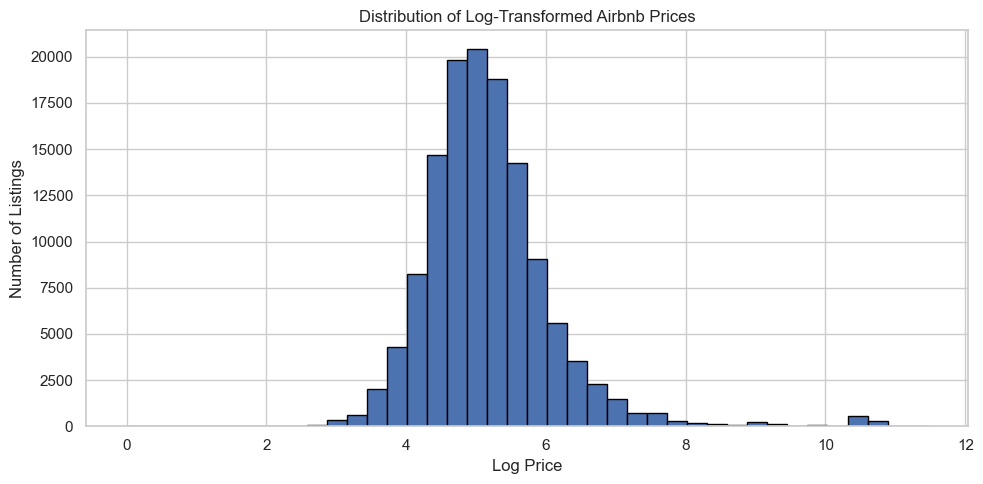

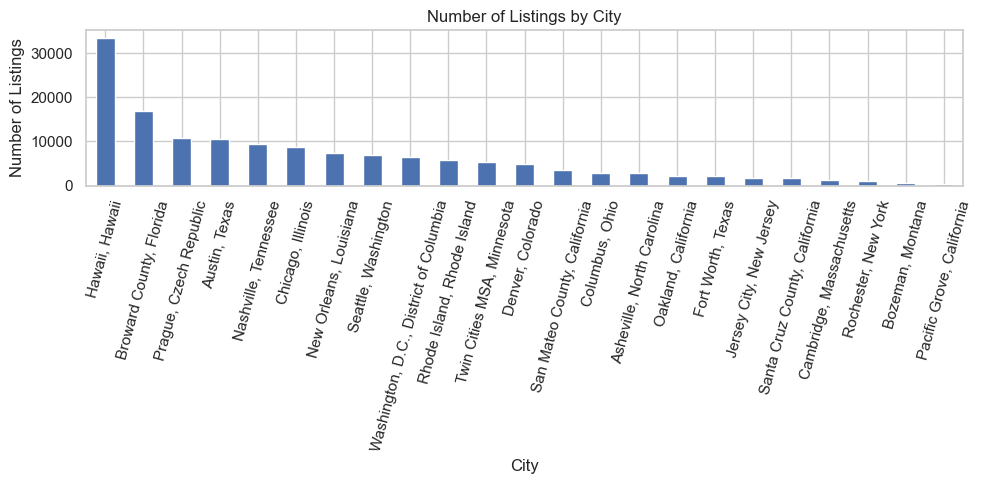

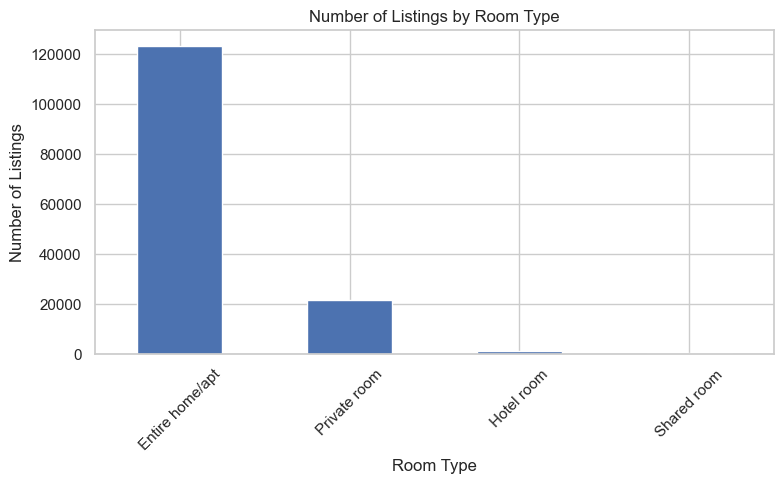

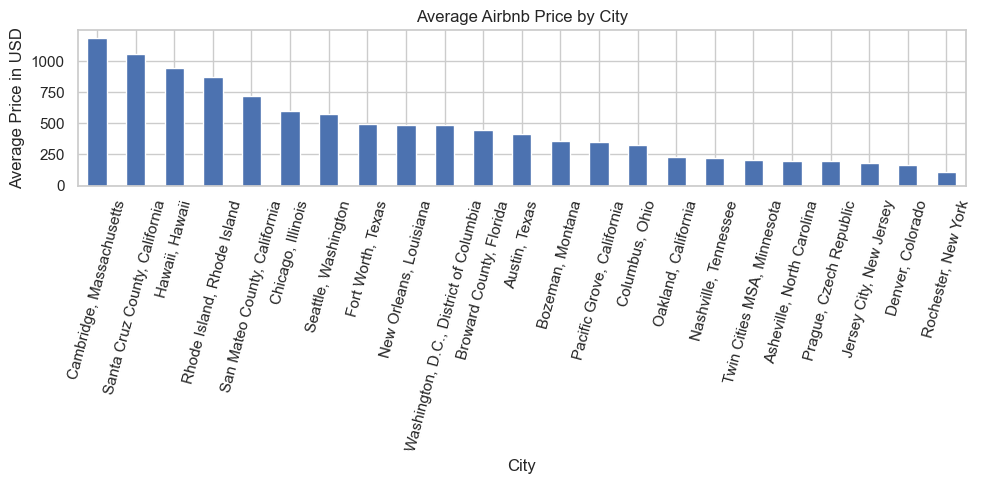

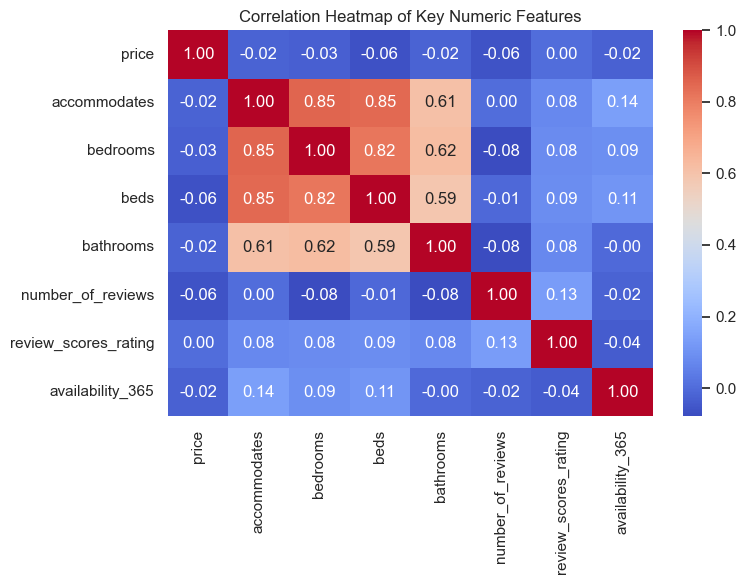

In [3]:
# =========================================
# 3. DATA EXPLORATION
# =========================================
print("Dataset shape:", df.shape)

print("\nCity counts before cleaning:")
print(df["city_full"].value_counts())

print("\nTop missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nPrice summary statistics:")
print(df["price"].describe())

print("\nAverage price by city:")
print(df.groupby("city_full")["price"].mean().sort_values(ascending=False))

print("\nTop 10 most expensive listings:")
print(df[["city_full", "price"]].sort_values("price", ascending=False).head(10))

plt.figure(figsize=(10, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.xlabel("Price in Dollars")
plt.ylabel("Number of Listings")
plt.title("Raw Airbnb Price Distribution")
plt.tight_layout()
plt.show()

price_95 = df["price"].quantile(0.95)

plt.figure(figsize=(10, 5))
plt.hist(df.loc[df["price"] <= price_95, "price"].dropna(), bins=40, edgecolor="black")
plt.xlabel("Price in Dollars")
plt.ylabel("Number of Listings")
plt.title("Airbnb Price Distribution up to the 95th Percentile")
plt.tight_layout()
plt.show()

log_price = np.log1p(df["price"])

plt.figure(figsize=(10, 5))
plt.hist(log_price.dropna(), bins=40, edgecolor="black")
plt.xlabel("Log Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Log-Transformed Airbnb Prices")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
df["city_full"].value_counts().plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Number of Listings")
plt.title("Number of Listings by City")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

if "room_type" in df.columns:
    plt.figure(figsize=(8, 5))
    df["room_type"].value_counts().plot(kind="bar")
    plt.xlabel("Room Type")
    plt.ylabel("Number of Listings")
    plt.title("Number of Listings by Room Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

city_avg_price_plot = df.groupby("city_full")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
city_avg_price_plot.plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Average Price in USD")
plt.title("Average Airbnb Price by City")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

candidate_cols = [
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "review_scores_rating",
    "availability_365"
]
existing_cols = [col for col in candidate_cols if col in df.columns]

if len(existing_cols) > 1:
    plt.figure(figsize=(8, 6))
    corr = df[existing_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap of Key Numeric Features")
    plt.tight_layout()
    plt.show()



  <h3>



  4) Data Cleaning



  </h3>



  <p>



  The target variable is cleaned by removing missing values and filtering extreme outliers within each



  city. A log transformation is then applied to stabilize the target distribution.



  </p>

Dataset shape after per-city 99 percent cutoff: (127675, 82)

City counts after cleaning:
city_full
Hawaii, Hawaii                            33029
Broward County, Florida                   11601
Austin, Texas                             10411
Prague, Czech Republic                     9403
Chicago, Illinois                          7749
Nashville, Tennessee                       6567
New Orleans, Louisiana                     6170
Seattle, Washington                        6158
Rhode Island, Rhode Island                 4964
Washington, D.C., District of Columbia     4849
Twin Cities MSA, Minnesota                 4713
Denver, Colorado                           4258
San Mateo County, California               2922
Columbus, Ohio                             2667
Asheville, North Carolina                  2511
Oakland, California                        1917
Fort Worth, Texas                          1837
Jersey City, New Jersey                    1614
Santa Cruz County, California       

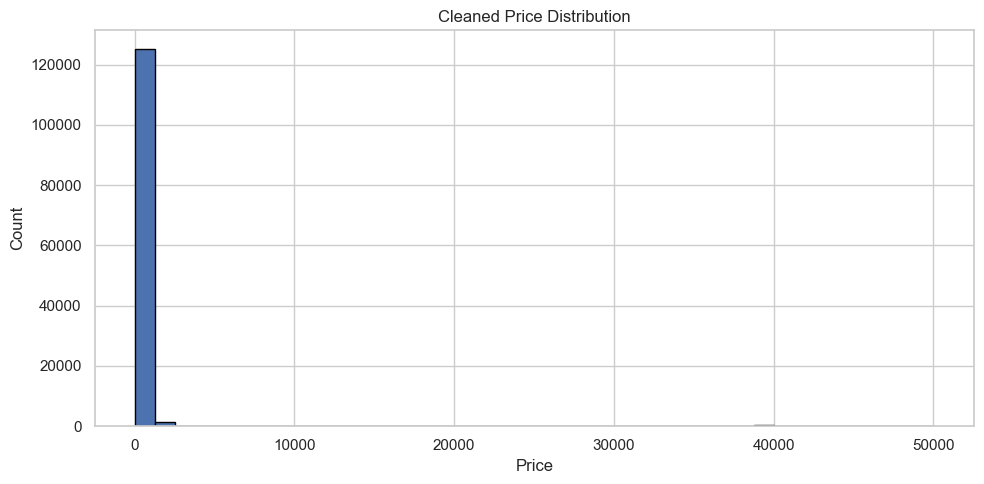

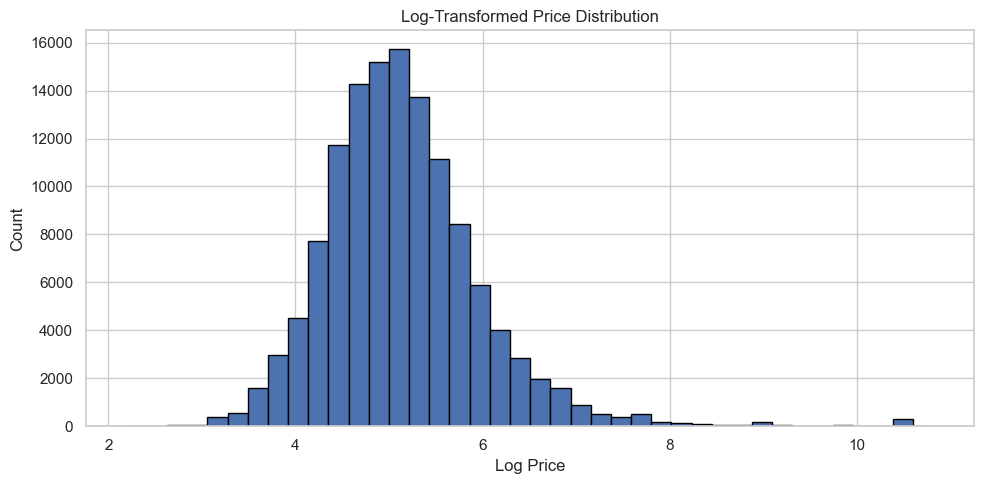

In [4]:
# =========================================
# 4. CLEAN TARGET VARIABLE
# =========================================
df = df.dropna(subset=["price"]).copy()
df = df[df["price"] > 0].copy()

city_counts = df["city_full"].value_counts()
keep_cities = city_counts[city_counts >= MIN_ROWS_PER_CITY].index
df = df[df["city_full"].isin(keep_cities)].copy()

# Remove top 1 percent within each city instead of top 5 percent
city_cutoff = df.groupby("city_full")["price"].transform(lambda x: x.quantile(TOP_CITY_OUTLIER_Q))
df = df[df["price"] <= city_cutoff].copy()

print("Dataset shape after per-city 99 percent cutoff:", df.shape)
print("\nCity counts after cleaning:")
print(df["city_full"].value_counts())

df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(10, 5))
plt.hist(df["price"].dropna(), bins=40, edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Cleaned Price Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["log_price"].dropna(), bins=40, edgecolor="black")
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.title("Log-Transformed Price Distribution")
plt.tight_layout()
plt.show()



  <h3>



  5) Feature Engineering



  </h3>



  <p>



  New features are created from dates, listing characteristics, review activity, and location patterns



  to improve model performance.



  </p>

In [5]:
# =========================================
# 5. DATETIME FEATURES
# =========================================
date_cols = ["host_since", "first_review", "last_review", "last_scraped", "calendar_last_scraped"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

reference_date = df["last_scraped"].max() if "last_scraped" in df.columns else pd.Timestamp.today()

if "host_since" in df.columns:
    df["host_tenure_days"] = (reference_date - df["host_since"]).dt.days

if "first_review" in df.columns:
    df["days_since_first_review"] = (reference_date - df["first_review"]).dt.days

if "last_review" in df.columns:
    df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days



In [6]:
# =========================================
# 6. FEATURE ENGINEERING
# =========================================

# Convert percentage columns
for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("%", "", regex=False)
        df[col] = df[col].replace("nan", np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert boolean-style columns
bool_map = {"t": 1, "f": 0, True: 1, False: 0}
for col in [
    "instant_bookable",
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "has_availability"
]:
    if col in df.columns:
        df[col] = df[col].map(bool_map)

# Extract numeric bathrooms from text
if "bathrooms_text" in df.columns:
    df["bathrooms_text_num"] = (
        df["bathrooms_text"]
        .astype(str)
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

if "bathrooms" in df.columns and "bathrooms_text_num" in df.columns:
    df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms_text_num"])
elif "bathrooms" not in df.columns and "bathrooms_text_num" in df.columns:
    df["bathrooms"] = df["bathrooms_text_num"]

# Count amenities
if "amenities" in df.columns:
    def count_amenities(x):
        try:
            return len(ast.literal_eval(x))
        except Exception:
            return np.nan

    df["amenities_count"] = df["amenities"].apply(count_amenities)

# Haversine distance from each city's median listing center
if "latitude" in df.columns and "longitude" in df.columns and "city_full" in df.columns:
    city_centers = (
        df.groupby("city_full")[["latitude", "longitude"]]
        .median()
        .rename(columns={"latitude": "center_lat", "longitude": "center_lon"})
    )

    df = df.merge(city_centers, on="city_full", how="left")

    def haversine_km(lat1, lon1, lat2, lon2):
        lat1 = np.radians(lat1)
        lon1 = np.radians(lon1)
        lat2 = np.radians(lat2)
        lon2 = np.radians(lon2)
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
        c = 2 * np.arcsin(np.sqrt(a))
        return 6371 * c

    df["distance_to_city_center"] = haversine_km(
        df["latitude"],
        df["longitude"],
        df["center_lat"],
        df["center_lon"]
    )

# Safe engineered features
if "bedrooms" in df.columns and "accommodates" in df.columns:
    df["bedroom_density"] = df["bedrooms"] / (df["accommodates"] + 1)

if "beds" in df.columns and "accommodates" in df.columns:
    df["bed_density"] = df["beds"] / (df["accommodates"] + 1)

if "beds" in df.columns and "bedrooms" in df.columns:
    df["beds_per_bedroom"] = df["beds"] / (df["bedrooms"] + 1)

if "availability_365" in df.columns:
    df["availability_ratio"] = df["availability_365"] / 365

if "number_of_reviews" in df.columns and "host_listings_count" in df.columns:
    df["reviews_per_listing"] = df["number_of_reviews"] / (df["host_listings_count"] + 1)

if "reviews_per_month" in df.columns and "host_listings_count" in df.columns:
    df["reviews_per_month_per_listing"] = df["reviews_per_month"] / (df["host_listings_count"] + 1)

if "number_of_reviews" in df.columns and "host_tenure_days" in df.columns:
    df["reviews_per_day"] = df["number_of_reviews"] / (df["host_tenure_days"] + 1)

if "availability_365" in df.columns and "number_of_reviews" in df.columns:
    df["availability_per_review"] = df["availability_365"] / (df["number_of_reviews"] + 1)

if "accommodates" in df.columns and "bedrooms" in df.columns:
    df["accommodates_x_bedrooms"] = df["accommodates"] * df["bedrooms"]

if "accommodates" in df.columns and "beds" in df.columns:
    df["accommodates_x_beds"] = df["accommodates"] * df["beds"]

if "number_of_reviews" in df.columns:
    df["log_number_of_reviews"] = np.log1p(df["number_of_reviews"])

if "minimum_nights" in df.columns:
    df["log_minimum_nights"] = np.log1p(df["minimum_nights"])

# Better per-city location clustering with adaptive cluster count
if "latitude" in df.columns and "longitude" in df.columns and "city_full" in df.columns:
    df["location_cluster"] = -1
    cluster_offset = 0

    for city_name in df["city_full"].unique():
        subset = df[df["city_full"] == city_name][["latitude", "longitude"]].dropna()

        if len(subset) < 50:
            continue

        n_clusters = int(np.clip(len(subset) // 250, 8, 30))
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(subset)

        df.loc[subset.index, "location_cluster"] = labels + cluster_offset
        cluster_offset += n_clusters

# Drop mostly missing columns
keep_force = {"price", "log_price", "city", "city_full", "latitude", "longitude", "neighbourhood_cleansed"}
keep_cols = [col for col in df.columns if (df[col].isnull().mean() < MAX_COL_MISSING) or (col in keep_force)]
df = df[keep_cols].copy()
df = df.dropna(axis=1, how="all")



  <h3>



  6) Train / Validation / Test Split



  </h3>



  <p>



  The dataset is split into train, validation, and test sets using a 60/20/20 split. Stratification



  by city keeps the city distribution balanced across splits.



  </p>

In [7]:
# =========================================
# 7. SELECT FEATURES
# =========================================
feature_cols = [
    "city",
    "city_full",
    "accommodates",
    "bathrooms",
    "bathrooms_text_num",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "availability_eoy",
    "estimated_occupancy_l365d",
    "host_response_rate",
    "host_acceptance_rate",
    "latitude",
    "longitude",
    "distance_to_city_center",
    "host_tenure_days",
    "days_since_first_review",
    "days_since_last_review",
    "amenities_count",
    "instant_bookable",
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "has_availability",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "host_response_time",
    "source",
    "bedroom_density",
    "bed_density",
    "beds_per_bedroom",
    "availability_ratio",
    "reviews_per_listing",
    "reviews_per_month_per_listing",
    "reviews_per_day",
    "availability_per_review",
    "accommodates_x_bedrooms",
    "accommodates_x_beds",
    "log_number_of_reviews",
    "log_minimum_nights",
    "location_cluster"
]

feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols].copy()
y = df["log_price"]

print("Number of selected features:", len(feature_cols))
print(feature_cols)



Number of selected features: 19
['city', 'city_full', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude', 'distance_to_city_center', 'days_since_last_review', 'room_type', 'neighbourhood_cleansed', 'availability_ratio', 'availability_per_review', 'log_number_of_reviews', 'log_minimum_nights', 'location_cluster']


In [8]:
# =========================================
# 8. TRAIN / DEV / TEST SPLIT
# =========================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=X["city_full"] if "city_full" in X.columns else None
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=X_train_full["city_full"] if "city_full" in X_train_full.columns else None
)

print("Train shape:", X_train.shape)
print("Dev shape:", X_dev.shape)
print("Test shape:", X_test.shape)

if "city_full" in X.columns:
    print("\nCity distribution in Train:")
    print(X_train["city_full"].value_counts(normalize=True))
    print("\nCity distribution in Dev:")
    print(X_dev["city_full"].value_counts(normalize=True))
    print("\nCity distribution in Test:")
    print(X_test["city_full"].value_counts(normalize=True))


# =========================================
# TRAIN-ONLY TARGET ENCODING FEATURES
# =========================================
def smoothed_target_mean(train_x, train_y, group_col, apply_x, min_count=25, smoothing=20):
    temp = train_x[[group_col]].copy()
    temp["price"] = np.expm1(train_y)

    global_mean = temp["price"].mean()
    stats = temp.groupby(group_col)["price"].agg(["mean", "count"])

    smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)
    smooth[stats["count"] < min_count] = global_mean

    return apply_x[group_col].map(smooth).fillna(global_mean)


# City average price learned from train only
X_train["city_avg_price"] = smoothed_target_mean(X_train, y_train, "city_full", X_train)
X_dev["city_avg_price"] = smoothed_target_mean(X_train, y_train, "city_full", X_dev)
X_test["city_avg_price"] = smoothed_target_mean(X_train, y_train, "city_full", X_test)

# Neighborhood average price learned from train only
if "neighbourhood_cleansed" in X_train.columns:
    X_train["neighborhood_avg_price"] = smoothed_target_mean(
        X_train, y_train, "neighbourhood_cleansed", X_train, min_count=30, smoothing=25
    )
    X_dev["neighborhood_avg_price"] = smoothed_target_mean(
        X_train, y_train, "neighbourhood_cleansed", X_dev, min_count=30, smoothing=25
    )
    X_test["neighborhood_avg_price"] = smoothed_target_mean(
        X_train, y_train, "neighbourhood_cleansed", X_test, min_count=30, smoothing=25
    )

print("\nAdded train-only city and neighborhood target encoding features.")



Train shape: (76605, 19)
Dev shape: (25535, 19)
Test shape: (25535, 19)

City distribution in Train:
city_full
Hawaii, Hawaii                            0.258691
Broward County, Florida                   0.090869
Austin, Texas                             0.081548
Prague, Czech Republic                    0.073651
Chicago, Illinois                         0.060688
Nashville, Tennessee                      0.051446
New Orleans, Louisiana                    0.048326
Seattle, Washington                       0.048234
Rhode Island, Rhode Island                0.038875
Washington, D.C., District of Columbia    0.037974
Twin Cities MSA, Minnesota                0.036904
Denver, Colorado                          0.033340
San Mateo County, California              0.022897
Columbus, Ohio                            0.020886
Asheville, North Carolina                 0.019672
Oakland, California                       0.015012
Fort Worth, Texas                         0.014399
Jersey City, New Jerse

  <h3>



  7) Modeling



  </h3>



  <p>



  Multiple models are compared, including a simple baseline, Ridge Regression, Random Forest, and



  tree-based ensemble methods. This helps determine whether more flexible models outperform simpler ones.



  </p>

In [9]:
# =========================================
# 9. PREPROCESSING PIPELINE
# =========================================
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

numeric_transformer_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ridge_preprocessor = ColumnTransformer([
    ("num", numeric_transformer_scaled, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

tree_preprocessor = ColumnTransformer([
    ("num", numeric_transformer_tree, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])



In [10]:
# =========================================
# 10. BASELINE AND MULTIPLE MODELS
# =========================================
baseline_pred_log = np.full(shape=len(y_dev), fill_value=y_train.mean())
baseline_mae_dollars = mean_absolute_error(np.expm1(y_dev), np.expm1(baseline_pred_log))
print("Baseline MAE in dollars:", baseline_mae_dollars)

models = {
    "Ridge": Pipeline([
        ("preprocessor", ridge_preprocessor),
        ("model", Ridge(alpha=3.0))
    ]),
    "RandomForest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            n_estimators=500,
            max_depth=30,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt"
        ))
    ]),
    "ExtraTrees": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", ExtraTreesRegressor(
            random_state=42,
            n_jobs=-1,
            n_estimators=500,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt"
        ))
    ])
}

results = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_dev)

    mae_log = mean_absolute_error(y_dev, preds)
    mae_dollars = mean_absolute_error(np.expm1(y_dev), np.expm1(preds))
    r2 = r2_score(y_dev, preds)

    results.append({
        "Model": name,
        "MAE_log": mae_log,
        "MAE_dollars": mae_dollars,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("MAE_dollars")
print(results_df)



Baseline MAE in dollars: 270.7932311731927
          Model   MAE_log  MAE_dollars        R2
1  RandomForest  0.373528   170.794518  0.638689
2    ExtraTrees  0.410895   210.737614  0.574172
0         Ridge  0.510069   254.111260  0.332333


  <h3>



  8) Hyperparameter Tuning



  </h3>



  <p>



  The strongest tree-based models are tuned using RandomizedSearchCV to improve predictive performance.



  </p>

In [11]:
# =========================================
# 11. RANDOM FOREST HYPERPARAMETER TUNING
# =========================================
rf_pipe = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [20, 30, 40, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_full, y_train_full)

print("Best Random Forest params:")
print(rf_search.best_params_)

best_model = rf_search.best_estimator_



Fitting 3 folds for each of 15 candidates, totalling 45 fits


ValueError: 
All the 45 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\iggyc\Downloads\.venv\Lib\site-packages\pandas\core\indexes\base.py", line 3641, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "pandas/_libs/index.pyx", line 168, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 197, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7668, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7676, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'city_avg_price'

The above exception was 

In [ ]:
# =========================================
# 12. XGBOOST MODEL
# =========================================
xgb_pipe = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=700,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)

xgb_dev_preds = xgb_pipe.predict(X_dev)

xgb_dev_mae_log = mean_absolute_error(y_dev, xgb_dev_preds)
xgb_dev_mae_dollars = mean_absolute_error(np.expm1(y_dev), np.expm1(xgb_dev_preds))
xgb_dev_r2 = r2_score(y_dev, xgb_dev_preds)

print("XGBoost Dev Results")
print("MAE (log):", xgb_dev_mae_log)
print("MAE (dollars):", xgb_dev_mae_dollars)
print("R2:", xgb_dev_r2)



In [ ]:
# =========================================
# 13. XGBOOST HYPERPARAMETER TUNING
# =========================================
xgb_tune_pipe = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_dist = {
    "model__n_estimators": [400, 700, 1000],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.05, 0.1, 0.5],
    "model__reg_lambda": [1.0, 1.5, 2.0, 3.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_tune_pipe,
    param_distributions=xgb_param_dist,
    n_iter=18,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_full, y_train_full)

print("Best XGBoost params:")
print(xgb_search.best_params_)

best_xgb_model = xgb_search.best_estimator_



  <h3>



  9) Model Evaluation



  </h3>



  <p>



  Final models are evaluated on the held-out test set using MAE and R². MAE is also converted back



  to dollar units for interpretation.



  </p>

In [ ]:
# =========================================
# 14. FINAL TEST EVALUATION FOR RANDOM FOREST
# =========================================
test_preds = best_model.predict(X_test)

test_mae_log = mean_absolute_error(y_test, test_preds)
test_mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(test_preds))
test_r2 = r2_score(y_test, test_preds)

print("\nFinal Test Results")
print("MAE (log):", test_mae_log)
print("MAE (dollars):", test_mae_dollars)
print("R2:", test_r2)



In [ ]:
# =========================================
# 15. FINAL TEST EVALUATION FOR XGBOOST
# =========================================
xgb_test_preds = best_xgb_model.predict(X_test)

xgb_test_mae_log = mean_absolute_error(y_test, xgb_test_preds)
xgb_test_mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(xgb_test_preds))
xgb_test_r2 = r2_score(y_test, xgb_test_preds)

print("\nFinal XGBoost Test Results")
print("MAE (log):", xgb_test_mae_log)
print("MAE (dollars):", xgb_test_mae_dollars)
print("R2:", xgb_test_r2)



In [ ]:
# =========================================
# 16. WEIGHTED ENSEMBLE MODEL
# =========================================
rf_preds_dev = best_model.predict(X_dev)
xgb_preds_dev = best_xgb_model.predict(X_dev)

best_weight = None
best_dev_mae = float("inf")

for w in np.linspace(0, 1, 21):
    blended_dev = (rf_preds_dev * w) + (xgb_preds_dev * (1 - w))
    blended_dev_mae = mean_absolute_error(np.expm1(y_dev), np.expm1(blended_dev))
    if blended_dev_mae < best_dev_mae:
        best_dev_mae = blended_dev_mae
        best_weight = w

print("\nBest Random Forest weight from dev set:", best_weight)
print("Best dev ensemble MAE:", best_dev_mae)

rf_preds = best_model.predict(X_test)
xgb_preds = best_xgb_model.predict(X_test)

ensemble_preds = (rf_preds * best_weight) + (xgb_preds * (1 - best_weight))

ensemble_mae = mean_absolute_error(
    np.expm1(y_test),
    np.expm1(ensemble_preds)
)

ensemble_r2 = r2_score(y_test, ensemble_preds)

print("\nEnsemble Results")
print("MAE (dollars):", ensemble_mae)
print("R2:", ensemble_r2)



In [ ]:
# =========================================
# 17. RELATIVE ERROR
# =========================================
mean_price = np.expm1(y_test).mean()
relative_error = ensemble_mae / mean_price

print("Mean price:", mean_price)
print("Relative error:", relative_error)



  <h3>



  Prediction Plots



  </h3>



  <p>



  These plots compare actual and predicted prices for the final Random Forest and XGBoost models.



  A tighter pattern along the diagonal indicates stronger predictive performance.



  </p>

In [ ]:
# =========================================
# 18. ACTUAL VS PREDICTED FOR RANDOM FOREST
# =========================================
actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(test_preds)

plt.figure(figsize=(8, 6))
plt.scatter(actual_prices, predicted_prices, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices - Random Forest")
plt.tight_layout()
plt.show()



In [ ]:
# =========================================
# 19. ACTUAL VS PREDICTED FOR XGBOOST
# =========================================
xgb_predicted_prices = np.expm1(xgb_test_preds)

plt.figure(figsize=(8, 6))
plt.scatter(actual_prices, xgb_predicted_prices, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices - XGBoost")
plt.tight_layout()
plt.show()



  <h3>



  10) Model Interpretation



  </h3>



  <p>



  Permutation importance is used to identify which original features most influence model performance.



  This helps explain the final model and highlights the strongest drivers of Airbnb pricing.



  </p>

In [ ]:
# =========================================
# 20. PERMUTATION IMPORTANCE
# =========================================
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Permutation Importances")
plt.tight_layout()
plt.show()



  <h3>



  11) Conclusion



  </h3>



  <p>



  This project developed machine learning models to predict Airbnb listing prices across many cities.



  After cleaning the data, engineering features, and comparing multiple models, the final tuned models



  achieved strong predictive performance.



  </p>



  <p>



  The results substantially improved over the baseline model, showing that the selected features and



  modeling pipeline capture important pricing patterns. Location-based variables, city-level pricing,



  neighborhood-level pricing, room type, and review activity were among the most useful predictors.



  </p>



  <p>



  Overall, the project demonstrates that machine learning methods can predict Airbnb prices with



  strong accuracy across multiple cities. Future improvements could include seasonal features,



  calendar availability patterns, or textual review information.



  </p>